# Cohort 1, Group 8 
Jessica Peng, Aryan Chopra, Alexandru Croitoru, Steven (Shaoxiong) Yuan, Zhou Yuxue (Charlie)

In [456]:
# Import all packages 
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
from pprint import pprint

In [457]:
# Technology Stocks
tech_stocks = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META", "TSLA", "AMD", "ORCL", "IBM"]

# Healthcare & Biotech Stocks
healthcare_stocks = ["JNJ", "PFE", "MRNA", "LLY", "UNH", "BMY", "GILD", "REGN", "BIIB", "VRTX"]

# Financial Stocks
financial_stocks = ["JPM", "BAC", "GS", "MS", "WFC", "C", "AXP", "PYPL", "SQ", "V"]

# Energy Stocks (really good performance)
energy_stocks = ["XOM", "CVX", "COP", "OXY", "SLB", "EOG", "HAL", "DVN", "PXD", "MPC"]

# Consumer Discretionary Stocks
consumer_discretionary_stocks = ["TSLA", "AMZN", "NKE", "MCD", "HD", "SBUX", "DIS", "LOW", "TJX", "ROST"]

# Consumer Staples Stocks (decent alpha)
consumer_staples_stocks = ["PG", "KO", "PEP", "WMT", "COST", "MDLZ", "CL", "KMB", "TGT", "GIS"]

# Industrial Stocks
industrial_stocks = ["HON", "GE", "CAT", "BA", "LMT", "DE", "UPS", "UNP", "RTX", "EMR"]

# Real Estate Stocks (REITs)
real_estate_stocks = ["O", "SPG", "AMT", "PLD", "EQIX", "AVB", "EQR", "VNO", "SLG", "BXP"]

# Utilities Stocks
utilities_stocks = ["NEE", "DUK", "SO", "D", "XEL", "AEP", "ES", "PEG", "ED", "WEC"]

# Materials Stocks
materials_stocks = ["LIN", "SHW", "FCX", "APD", "NEM", "ECL", "DOW", "VMC", "MLM", "ALB"]

In [458]:
# Create stock lists
indices = ['^SPX', '^NDX', '^RUT', '^DJI']  # list of indexes
mag7 = ['AAPL', 'META', 'AMZN', 'NVDA', 'TSLA', 'MSFT', 'GOOG', '^SPX'] # magnificent 7 stocks
spx = ['^SPX']
volatile_stocks = ["TSLA", "NVDA", "GME", "AMC", "MRNA", "COIN", "PLTR", "ARKK", "RIOT", "BYND"]

#sectors = ['XLC', 'XLY', 'XLP', 'XLE', 'XLF', 'XLV', 'XLI', 'XLB', 'XLRE', 'XLK', 'XLU'] # 11 sectors of S&P 500
portfolio = ['AAPL', 'TSLA', 'BA', 'JPM']
random = ['^GSPE']

analysis_choice = random

# Define date range
start_date = "2020-01-01"
end_date = "2024-12-31"
small_timeframe = 8
big_timeframe = 25

In [459]:
# Fetch historical risk-free rate data
risk_free_symbol = "^IRX"

# Download risk-free rate data
risk_free_data = yf.download(risk_free_symbol, start=start_date, end=end_date)

risk_free_data['Daily_Return'] = risk_free_data['Close'].pct_change()/100
risk_free_data['Cumulative_Return'] = (1 + risk_free_data['Daily_Return']).cumprod() - 1

# risk_free_data

[*********************100%***********************]  1 of 1 completed


In [460]:

risk_free_data["Rate"] = risk_free_data["Close"] / 100  # Convert from percentage (bps) to decimal
average_risk_free_rate = risk_free_data["Rate"].mean()

# average_risk_free_rate

In [461]:
# Calculate golden/death EMA cross strategy returns - no shorting

def ema_cross_strategy(df, short_time_span, long_time_span) -> pd.DataFrame:
    """
    Applies a golden-cross & death-cross EMA strategy to the given DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a 'Close' column containing asset prices.
    short_time_span : int
        The time span for the short-term EMA.
    long_time_span : int
        The time span for the long-term EMA.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with additional columns:
        - 'EMA_short': short-term exponential moving average.
        - 'EMA_long': long-term exponential moving average.
        - 'Signal': 'Buy' if a golden cross occurred, 'Sell' if a death cross occurred.
        - 'Percent_Change': daily percent change of closing price.
        - 'Position': share holding (set to 1 on a buy signal, 0 on a sell signal, and 0 otherwise, forward-filled).
        - 'Daily_Return': daily return of the strategy.
        - 'Strategy_Cumulative_Return': cumulative return of the strategy.
        - 'Buy_And_Hold_Return': cumulative return of a buy-and-hold strategy.
    """

    # Create short and long EMA with a minimum number of periods so the EMA isn’t computed until enough data is available
    df['EMA_short'] = df['Close'].ewm(span = short_time_span, adjust = False, min_periods = short_time_span).mean()
    df['EMA_long']  = df['Close'].ewm(span = long_time_span, adjust = False, min_periods = long_time_span).mean()

    # Initialize the 'Signal' column
    df['Signal'] = None

    # Identify when EMA_short crosses over EMA_long (buy signal)
    df.loc[(df['EMA_short'] > df['EMA_long']) & (df['EMA_short'].shift(1) < df['EMA_long'].shift(1)), 'Signal'] = 'Buy'

    # Identify when EMA_short crosses under EMA_long (sell signal)
    df.loc[(df['EMA_short'] < df['EMA_long']) & (df['EMA_short'].shift(1) > df['EMA_long'].shift(1)), 'Signal'] = 'Sell'

    # Calculate daily percent change
    df['Percent_Change'] = df['Close'].pct_change()

    # Initialize position to 0 (no position)
    df['Position'] = np.nan

    # When a buy or sell signal occurs, assign the respective position
    df.loc[df['Signal'] == 'Buy', 'Position'] = 1
    df.loc[df['Signal'] == 'Sell', 'Position'] = 0

    # Forward-fill the position so that once a signal is triggered, the position holds until the next signal
    df['Position'] = df['Position'].ffill().fillna(0)

    # Calculate daily return based on the position, assume we transact at close when signal is triggered 
    df['Daily_Return'] = df['Position'].shift(1) * df['Percent_Change']

    # Compute cumulative returns for the strategy and for buy-and-hold
    df['Strategy_Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1
    df['Buy_And_Hold_Return'] = (1 + df['Percent_Change']).cumprod() - 1

    return df


In [462]:
# Define a function to run EMA cross strategy on a list of stock tickers

def strategy_returns(stock_list, start_date, end_date, short_time_span, long_time_span) -> pd.DataFrame:
    """
    Calculates the cumulative returns for an EMA cross trading strategy across multiple stocks.

    For each stock in the provided list:
    - Historical price data is downloaded for the specified date range.
    - The EMA cross strategy is applied to compute trading signals and cumulative returns.
    - The strategy's cumulative return and a buy-and-hold return are extracted and stored in a results DataFrame.

    The function returns a DataFrame with columns for each stock's strategy return and buy-and-hold return.
    """

def strategy_returns(stock_list, start_date, end_date, short_time_span, long_time_span) -> pd.DataFrame:
    # Initialize an empty DataFrame to store returns for each stock.
    returns = pd.DataFrame()
    
    # Iterate through each stock ticker in the provided list.
    for stock in stock_list:
        
        # Download historical price data for the stock within the given date range using yfinance.
        df = yf.download(stock, start_date, end_date)
        
        # If the data comes with multi-level columns (e.g., from yfinance), drop the extra level to simplify column names.
        df.columns = df.columns.droplevel(level=1)

        # Apply the EMA cross strategy to the DataFrame.
        ema_cross_strategy(df, short_time_span, long_time_span)
    
        # Store the strategy's cumulative return in the returns DataFrame.
        returns[stock + '_Strategy_Return'] = df['Strategy_Cumulative_Return']
        
        # Store the buy-and-hold cumulative return in the returns DataFrame.
        returns[stock + '_Hold_Return'] = df['Buy_And_Hold_Return']

    # Return the DataFrame containing both strategy and buy-and-hold returns for each stock.
    return returns

In [463]:
def calculate_performance_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes performance metrics: annual return, annual volatility, Sharpe ratio, and max drawdown.
    """

    trading_days = 252  # Number of trading days in a year
    results = {}

    numeric_columns = df.select_dtypes(include=[np.number]).columns

    for column in df.columns:
        # Convert cumulative returns to daily returns
        daily_returns = df[column].pct_change().dropna()

        # 🔹 Fix: Replace NaNs/Infs in returns
        daily_returns.replace([np.inf, -np.inf], np.nan, inplace=True)
        daily_returns.fillna(0, inplace=True)

        # 🔹 Fix Annualized Return (Use Log Returns)
        log_daily_returns = np.log(1 + daily_returns.replace([np.inf, -np.inf], np.nan).dropna())
        annual_return = log_daily_returns.mean() * trading_days

        # 🔹 Fix Annualized Volatility (Handle NaNs)
        annual_volatility = daily_returns.std() * np.sqrt(trading_days)

        # 🔹 Fix Sharpe Ratio (Avoid NaN issues)
        excess_daily_returns = daily_returns - (average_risk_free_rate / trading_days)
        sharpe_ratio = (
            excess_daily_returns.mean() / excess_daily_returns.std() * np.sqrt(trading_days)
            if excess_daily_returns.std() > 0 else np.nan
        )

        # 🔹 Fix Maximum Drawdown (Handle NaNs)
        cumulative_max = df[column].cummax()
        drawdown = df[column] / cumulative_max - 1
        max_drawdown = drawdown.min()

        # Store results
        results[column] = {
            "Annual Return": annual_return,
            "Annual Volatility": annual_volatility,
            "Sharpe Ratio": sharpe_ratio,
            "Max Drawdown": max_drawdown,
        }

    return pd.DataFrame(results).T


In [464]:
# Run strategy
returns_df = strategy_returns(analysis_choice, start_date, end_date, small_timeframe, big_timeframe)
returns_df = returns_df.join(risk_free_data['Cumulative_Return'].rename('Risk_Free_Cumulative_Return'))

# Compute performance metrics
performance_metrics_df = calculate_performance_metrics(returns_df)


[*********************100%***********************]  1 of 1 completed
C:\Users\alexa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [465]:
# returns_df

In [466]:
# Create portfolio returns by computing an equal-weighted average of each stock's returns
# Calculate portfolio strategy return as the average of individual strategy returns
strategy_return_cols = [stock + '_Strategy_Return' for stock in analysis_choice]
returns_df['Portfolio_Strategy_Return'] = returns_df[strategy_return_cols].mean(axis=1)

# Calculate portfolio buy-and-hold return as the average of individual buy-and-hold returns
hold_return_cols = [stock + '_Hold_Return' for stock in analysis_choice]
returns_df['Portfolio_Hold_Return'] = returns_df[hold_return_cols].mean(axis=1)

# Create a new DataFrame containing only the portfolio returns
portfolio_returns = returns_df[['Portfolio_Strategy_Return', 'Portfolio_Hold_Return']]

# Compute performance metrics for the portfolio using the previously defined function
portfolio_performance = calculate_performance_metrics(portfolio_returns)


# portfolio_performance

C:\Users\alexa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [467]:
# performance_metrics_df
# returns_df

In [468]:
# Function to plot cumulative daily returns for SPX only
def plot_spx_cumulative_returns(df: pd.DataFrame, title: str = "Cumulative Daily Returns for SPX"):
    """
    Plots the cumulative daily returns for SPX strategy and buy-and-hold return.

    Parameters:
    df : pd.DataFrame
        A DataFrame containing cumulative returns for different stocks/strategies.
    title : str
        The title of the plot.
    """
    plt.figure(figsize=(12, 8))

    # Filter for SPX-related columns only
    spx_columns = [col for col in df.columns]
    # spx_columns = [col for col in df.columns if "Free" in col]


    for column in spx_columns:
        plt.plot(df.index, df[column], label=column)

    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# # Call the function after ensuring `returns_df` is available
# plot_spx_cumulative_returns(portfolio_returns, title="Cumulative Daily Returns: SPX Strategy vs. Buy-and-Hold")

In [469]:
# returns_df
# print(performance_metrics_df)

C:\Users\alexa\AppData\Local\Temp\ipykernel_23912\3853820061.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  returns_df['Rolling_Sharpe_Ratio'].fillna(0, inplace=True)  # Avoid NaNs
C:\Users\alexa\AppData\Local\Temp\ipykernel_23912\3853820061.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]
C:\Users\alexa\AppDa

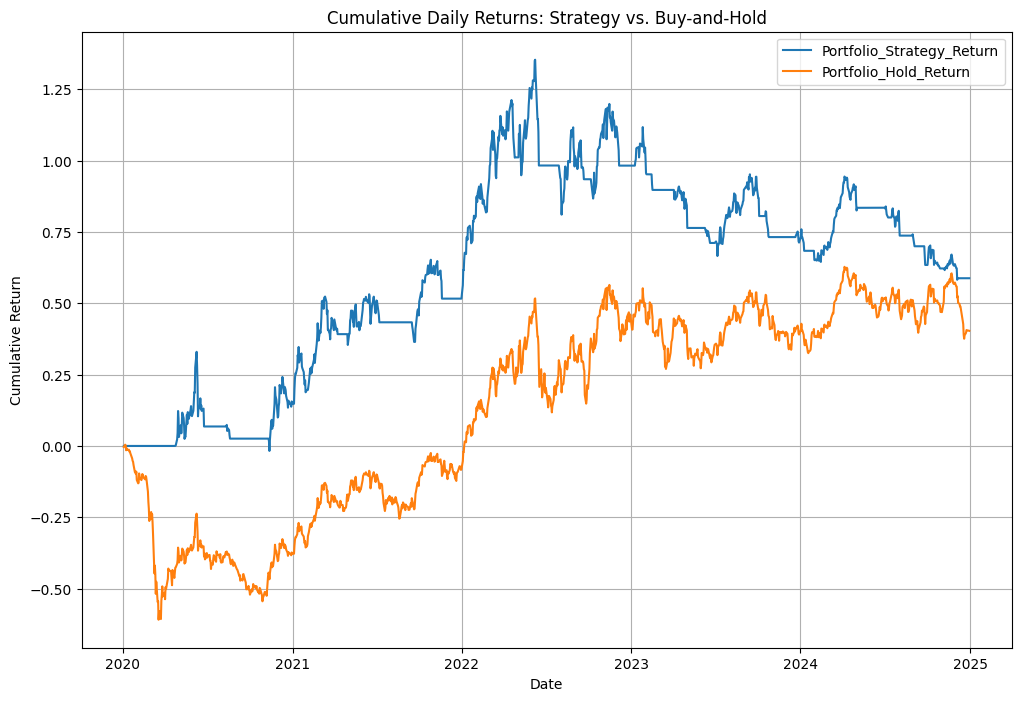

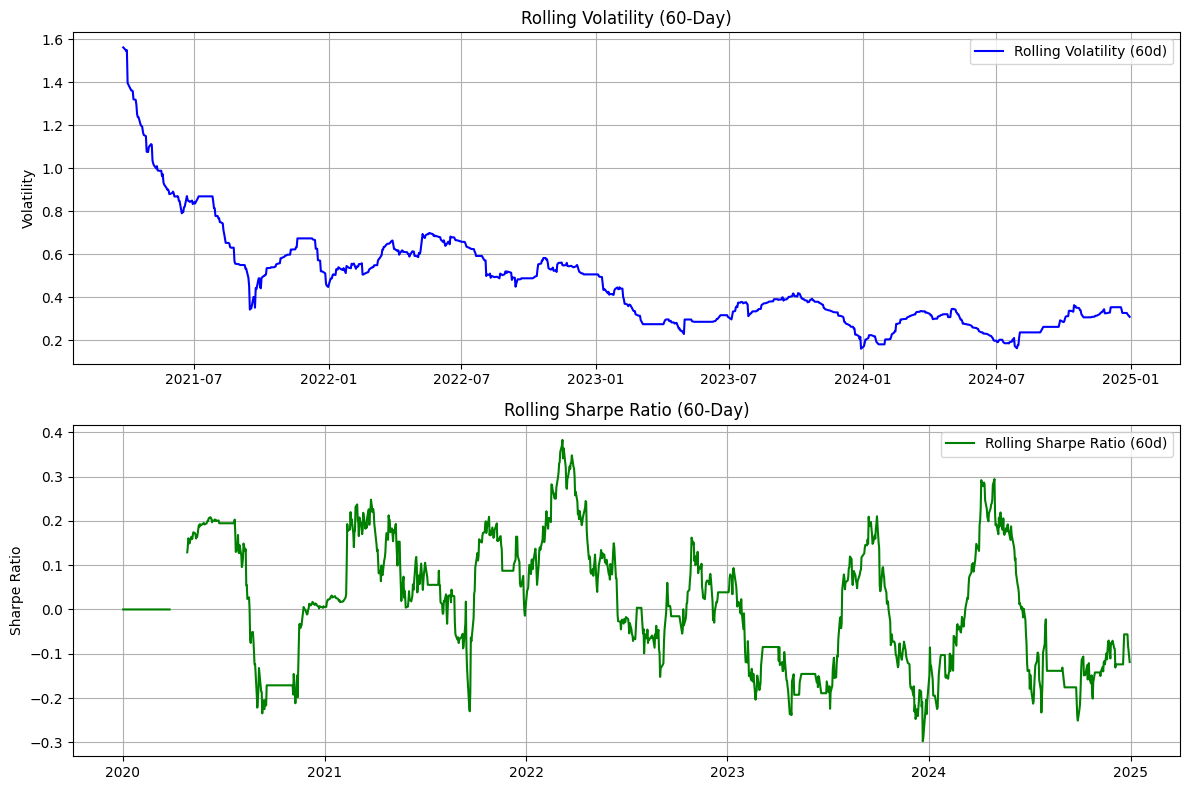

                             OLS Regression Results                            
Dep. Variable:     Strat_Daily_Returns   R-squared:                       0.000
Model:                             OLS   Adj. R-squared:                 -0.001
Method:                  Least Squares   F-statistic:                    0.1437
Date:                 Wed, 12 Mar 2025   Prob (F-statistic):              0.705
Time:                         14:38:19   Log-Likelihood:                -408.20
No. Observations:                 1257   AIC:                             820.4
Df Residuals:                     1255   BIC:                             830.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0

In [472]:
import statsmodels.api as sm

rolling_window = 60
strategy_col = returns_df['Portfolio_Strategy_Return']
hold_col = returns_df['Portfolio_Hold_Return']


# # Ensure that the columns exist in the DataFrame
# if 'Portfolio_Strategy_Return' not in returns_df.columns or 'Portfolio_Hold_Return' not in returns_df.columns:
#     raise KeyError("The required columns 'Portfolio_Strategy_Return' and 'Portfolio_Hold_Return' are not in the DataFrame.")

rolling_window = 60
strategy_col = 'Portfolio_Strategy_Return'
hold_col = 'Portfolio_Hold_Return'

# Calculate daily returns
returns_df['Strat_Daily_Returns'] = returns_df[strategy_col].pct_change()
returns_df['Hold_Daily_Returns'] = returns_df[hold_col].pct_change()

# Replace inf and -inf values with NaN, then fill NaN values with 0
returns_df.replace([np.inf, -np.inf], np.nan, inplace=True)
returns_df.fillna(0, inplace=True)



# Rolling Volatility
returns_df['Rolling_Volatility'] = returns_df['Strat_Daily_Returns'].rolling(rolling_window).std() * np.sqrt(252)

# Rolling Sharpe Ratio
excess_returns = returns_df['Strat_Daily_Returns'] - (average_risk_free_rate / 252)
returns_df['Rolling_Sharpe_Ratio'] = excess_returns.rolling(rolling_window).mean() / excess_returns.rolling(rolling_window).std()
returns_df['Rolling_Sharpe_Ratio'].fillna(0, inplace=True)  # Avoid NaNs
# returns_df.fillna({['Rolling_Sharpe_Ratio']: 0}, inplace=True)  # Avoid NaNs

# df.method({col: value}, inplace=True)

# Slice the DataFrame to start plotting a few days later
start_index = rolling_window + 250  # Adjust the number of days as needed
# start_index = rolling_window  # Adjust the number of days as needed
plot_df = returns_df.iloc[start_index:]


regression_data = returns_df[['Strat_Daily_Returns', 'Hold_Daily_Returns']].dropna()

regression_data.replace([np.inf, -np.inf], np.nan, inplace=True)
regression_data.fillna(0, inplace=True)

X = regression_data['Hold_Daily_Returns']
y = regression_data['Strat_Daily_Returns']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
beta = model.params[1]

returns_df['Performance_Alpha'] = returns_df['Strat_Daily_Returns'] - (beta * returns_df['Hold_Daily_Returns'])

# Replace inf and -inf values with NaN, then fill NaN values with 0
returns_df['Performance_Alpha'].replace([np.inf, -np.inf], np.nan, inplace=True)
returns_df['Performance_Alpha'].fillna(0, inplace=True)

average_alpha = returns_df['Performance_Alpha'].mean()

# Call the function after ensuring `returns_df` is available
plot_spx_cumulative_returns(portfolio_returns, title="Cumulative Daily Returns: Strategy vs. Buy-and-Hold")
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Rolling Volatility Plot
ax[0].plot(plot_df.index, plot_df['Rolling_Volatility'], label='Rolling Volatility (60d)', color='blue')
# ax[0].plot(returns_df.index, returns_df['Rolling_Volatility'], label='Rolling Volatility (60d)', color='blue')
ax[0].set_title("Rolling Volatility (60-Day)")
ax[0].set_ylabel("Volatility")
ax[0].grid(True)
ax[0].legend()

# Rolling Sharpe Ratio Plot
# ax[1].plot(plot_df.index, plot_df['Rolling_Sharpe_Ratio'], label='Rolling Sharpe Ratio (60d)', color='green')
ax[1].plot(returns_df.index, returns_df['Rolling_Sharpe_Ratio'], label='Rolling Sharpe Ratio (60d)', color='green')
ax[1].set_title("Rolling Sharpe Ratio (60-Day)")
ax[1].set_ylabel("Sharpe Ratio")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()
print(model.summary())

stats = {
    "Portfolio Beta": beta,
    "Average Alpha": average_alpha,
    "First 5 Performance Alpha values": returns_df['Performance_Alpha'].dropna().tail()
}
print(portfolio_performance, stats)